In [7]:
import matplotlib.pyplot as plt
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from xgboost import XGBClassifier

# Temizlenmiş Veri Setini Yükleme
bundle = joblib.load("../backend/models/bankloan/bankloan_data_bundle.pkl")

X_train = bundle["X_train"]
X_test = bundle["X_test"]
y_train = bundle["y_train"]
y_test = bundle["y_test"]

print("Veriler başarıyla yüklendi!")
print(f"X_train boyutu: {X_train.shape}, X_test boyutu: {X_test.shape}")

Veriler başarıyla yüklendi!
X_train boyutu: (4000, 5), X_test boyutu: (1000, 5)


In [14]:
# Modeli Tanımlama
xg_model= XGBClassifier(
                subsample=0.8,
                n_estimators=180,
                min_child_weight=3,
                max_depth=2,
                learning_rate=0.05,
                colsample_bytree=1.0,
                random_state=42,
            )

In [15]:
# K-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xg_model, X_train, y_train, cv=cv, scoring="accuracy")

print("K-Fold (5 Katlı) Doğrulama Skorları:", cv_scores)
print("Ortalama CV Doğruluğu: {:.4f} (+/- {:.4f})".format(cv_scores.mean(), cv_scores.std() * 2))

K-Fold (5 Katlı) Doğrulama Skorları: [0.98625 0.98125 0.98    0.98375 0.98125]
Ortalama CV Doğruluğu: 0.9825 (+/- 0.0045)


In [16]:
# Tüm Eğitim Verisiyle Modeli Son Kez Eğitme
xg_model.fit(X_train, y_train)
print("\nModel tüm eğitim setiyle son kez eğitildi!")


Model tüm eğitim setiyle son kez eğitildi!


In [17]:
# Train Seti Performansı (Overfitting kontrolü için)
y_train_pred = xg_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

print("=" * 40)
print("          TRAIN SETİ PERFORMANSI          ")
print("=" * 40)
print(f"Train Doğruluk Oranı (Accuracy): {train_accuracy:.4f}\n")
print("Train Sınıflandırma Raporu (Precision, Recall, F1-Score):")
print(classification_report(y_train, y_train_pred))

# Test Seti Performansı (Gerçek başarı)
y_test_pred = xg_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 40)
print("          TEST SETİ PERFORMANSI           ")
print("=" * 40)
print(f"Test Doğruluk Oranı (Accuracy): {test_accuracy:.4f}\n")
print("Test Sınıflandırma Raporu (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_test_pred))

          TRAIN SETİ PERFORMANSI          
Train Doğruluk Oranı (Accuracy): 0.9858

Train Sınıflandırma Raporu (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3616
           1       0.96      0.89      0.92       384

    accuracy                           0.99      4000
   macro avg       0.97      0.94      0.96      4000
weighted avg       0.99      0.99      0.99      4000

          TEST SETİ PERFORMANSI           
Test Doğruluk Oranı (Accuracy): 0.9890

Test Sınıflandırma Raporu (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       904
           1       0.95      0.94      0.94        96

    accuracy                           0.99      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.99      0.99      0.99      1000



In [18]:
# Nihai Modeli Backend Altına Kaydetme
joblib.dump(xg_model, "../backend/models/student/xg_model.pkl")
print("Eğitilmiş model başarıyla kaydedildi!")

Eğitilmiş model başarıyla kaydedildi!


--- Öznitelik Önem Düzeyleri ---
     Feature  Importance
0     Income    0.390226
2  Education    0.328949
4     Family    0.180636
1      CCAvg    0.085421
3   Mortgage    0.014767


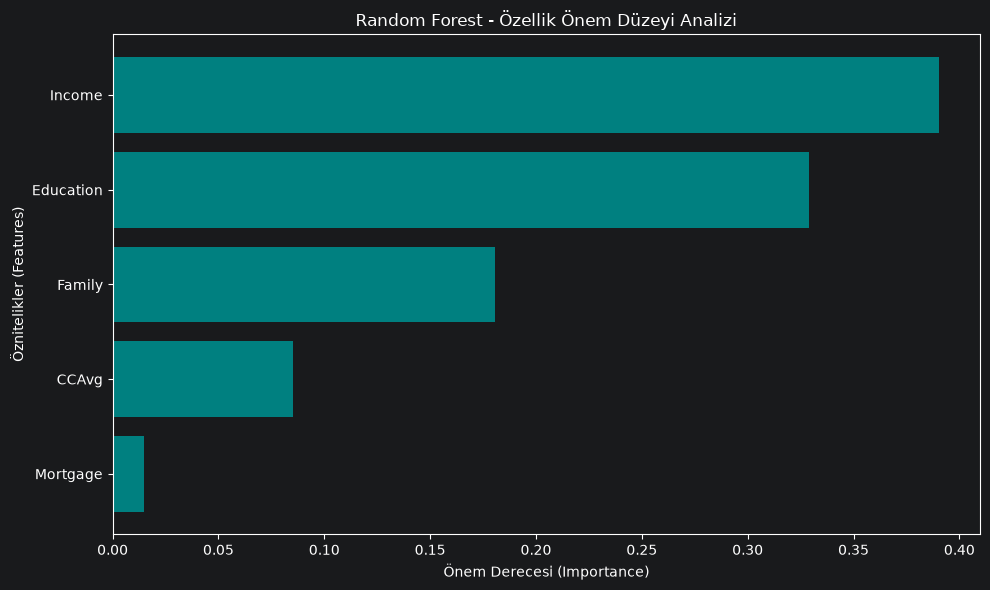

In [19]:
# 1. Özellik önem derecelerini modelden çekelim
importances = xg_model.feature_importances_
feature_names = (
    X_train.columns
)  # X_train hangi sütunlarla eğitildiyse onların adını alır

# 2. DataFrame'e dönüştürüp büyükten küçüğe sıralayalım
feature_imp_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
)
feature_imp_df = feature_imp_df.sort_values(by="Importance", ascending=False)

print("--- Öznitelik Önem Düzeyleri ---")
print(feature_imp_df)

# 3. Grafik olarak görselleştirelim (Rapora eklemek için mükemmeldir)
plt.figure(figsize=(10, 6))
plt.barh(
    feature_imp_df["Feature"], feature_imp_df["Importance"], color="teal"
)
plt.xlabel("Önem Derecesi (Importance)")
plt.ylabel("Öznitelikler (Features)")
plt.title("Random Forest - Özellik Önem Düzeyi Analizi")
plt.gca().invert_yaxis()  # En yüksek olan en üstte gözüksün
plt.tight_layout()
plt.show()

In [20]:
# 1. Orijinal ham CSV dosyasını doğrudan oku
df = pd.read_csv("../datasets/bankloan.csv")  # Yolunu kendi klasörüne göre ayarlarsın

# 2. X ve y olarak ayır
X = df.drop(
    "Personal.Loan", axis=1
)  # Kendi hedef sütun adını yazmalısın
y = df["Personal.Loan"]

# 3. Train-Test olarak böl (Analiz notebook'undaki test_size ve random_state AYNİ olmalı!)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Ham veri yüklendi ve bölündü!")

# 4. Modeli ham veriyle eğit
xg_raw_model= XGBClassifier(
                subsample=0.8,
                n_estimators=180,
                min_child_weight=3,
                max_depth=2,
                learning_rate=0.05,
                colsample_bytree=1.0,
                random_state=42,
            )
xg_raw_model.fit(X_train_raw, y_train)

# 5. Ham Model İçin Train Seti Performansı
y_train_pred_raw = xg_raw_model.predict(X_train_raw)
train_accuracy_raw = accuracy_score(y_train, y_train_pred_raw)

print("=" * 40)
print("      HAM VERİ - TRAIN SETİ PERFORMANSI      ")
print("=" * 40)
print(f"Train Doğruluk Oranı (Accuracy): {train_accuracy_raw:.4f}\n")
print("Train Sınıflandırma Raporu (Precision, Recall, F1-Score):")
print(classification_report(y_train, y_train_pred_raw))

# 6. Ham Model İçin Test Seti Performansı (Gerçek başarı)
y_test_pred_raw = xg_raw_model.predict(X_test_raw)
test_accuracy_raw = accuracy_score(y_test, y_test_pred_raw)

print("=" * 40)
print("      HAM VERİ - TEST SETİ PERFORMANSI       ")
print("=" * 40)
print(f"Test Doğruluk Oranı (Accuracy): {test_accuracy_raw:.4f}\n")
print("Test Sınıflandırma Raporu (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_test_pred_raw))

Ham veri yüklendi ve bölündü!
      HAM VERİ - TRAIN SETİ PERFORMANSI      
Train Doğruluk Oranı (Accuracy): 0.9868

Train Sınıflandırma Raporu (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3616
           1       0.97      0.89      0.93       384

    accuracy                           0.99      4000
   macro avg       0.98      0.94      0.96      4000
weighted avg       0.99      0.99      0.99      4000

      HAM VERİ - TEST SETİ PERFORMANSI       
Test Doğruluk Oranı (Accuracy): 0.9900

Test Sınıflandırma Raporu (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       904
           1       0.95      0.95      0.95        96

    accuracy                           0.99      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.99      0.99      0.99      1000

